# Task 1 - Data Analysis and Preprocessing
### Fraud Detection | 10 Academy KAIM9 | Eleni Melkie
### Notebook: eda-fraud-data.ipynb

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [52]:
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df    = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
cc_df    = pd.read_csv('../data/raw/creditcard.csv')

print("Fraud_Data shape:          ", fraud_df.shape)
print("IpAddress_to_Country shape:", ip_df.shape)
print("creditcard shape:          ", cc_df.shape)

Fraud_Data shape:           (151112, 11)
IpAddress_to_Country shape: (138846, 3)
creditcard shape:           (284807, 31)


In [53]:
print("=== Fraud_Data (first 5 rows) ===")
display(fraud_df.head())

print("\n=== IpAddress_to_Country (first 5 rows) ===")
display(ip_df.head())

print("\n=== creditcard (first 5 rows) ===")
display(cc_df.head())

=== Fraud_Data (first 5 rows) ===


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0



=== IpAddress_to_Country (first 5 rows) ===


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China



=== creditcard (first 5 rows) ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [54]:
print("=== Fraud_Data Info ===")
fraud_df.info()

print("\n=== Missing Values ===")
print(fraud_df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", fraud_df.duplicated().sum())

=== Fraud_Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB

=== Missing Values ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0


In [55]:
print("=== Creditcard Info ===")
cc_df.info()

print("\n=== Missing Values ===")
print(cc_df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", cc_df.duplicated().sum())

=== Creditcard Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

In [56]:
# Convert timestamps to datetime
fraud_df['signup_time']   = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Remove duplicates
fraud_df = fraud_df.drop_duplicates()
cc_df    = cc_df.drop_duplicates()

# Confirm
print("Fraud_Data after cleaning:", fraud_df.shape)
print("Creditcard after cleaning:", cc_df.shape)
print("✅ Data types fixed, duplicates removed!")

Fraud_Data after cleaning: (151112, 11)
Creditcard after cleaning: (283726, 31)
✅ Data types fixed, duplicates removed!


In [57]:
# Check missing values percentage
print("=== Fraud_Data Missing % ===")
missing_pct = (fraud_df.isnull().sum() / len(fraud_df)) * 100
print(missing_pct[missing_pct > 0])

# If no missing values:
print("\nNo missing values found — no imputation needed.")

# Drop rows with any remaining nulls (safety net)
fraud_df = fraud_df.dropna()
cc_df    = cc_df.dropna()

print("✅ Missing values handled!")
print("Fraud_Data shape:", fraud_df.shape)
print("Creditcard shape:", cc_df.shape)

=== Fraud_Data Missing % ===
Series([], dtype: float64)

No missing values found — no imputation needed.
✅ Missing values handled!
Fraud_Data shape: (151112, 11)
Creditcard shape: (283726, 31)


=== Fraud_Data Class Distribution ===
class
0    136961
1     14151
Name: count, dtype: int64

Fraud %: 9.36 %


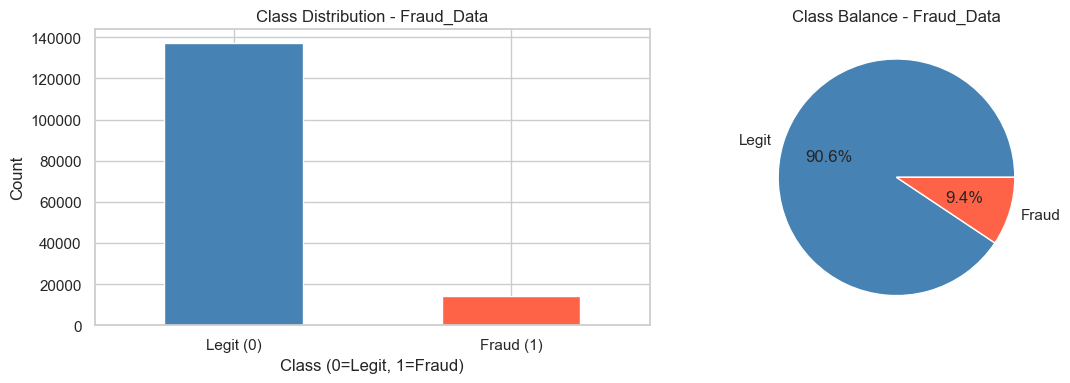

✅ Saved class distribution plot!


In [58]:
print("=== Fraud_Data Class Distribution ===")
print(fraud_df['class'].value_counts())
print("\nFraud %:", round(fraud_df['class'].mean() * 100, 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
fraud_df['class'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Class Distribution - Fraud_Data')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)

# Pie chart
fraud_df['class'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Legit', 'Fraud'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%'
)
axes[1].set_title('Class Balance - Fraud_Data')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/fraud_class_distribution.png', dpi=150)
plt.show()
print("✅ Saved class distribution plot!")

=== Creditcard Class Distribution ===
Class
0    283253
1       473
Name: count, dtype: int64

Fraud %: 0.17 %


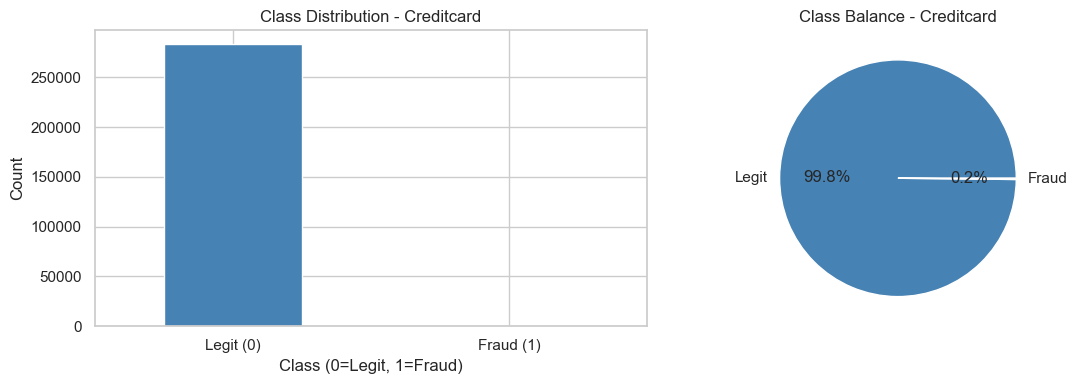

In [59]:
print("=== Creditcard Class Distribution ===")
print(cc_df['Class'].value_counts())
print("\nFraud %:", round(cc_df['Class'].mean() * 100, 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cc_df['Class'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Class Distribution - Creditcard')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)

cc_df['Class'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Legit', 'Fraud'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%'
)
axes[1].set_title('Class Balance - Creditcard')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_class_distribution.png', dpi=150)
plt.show()

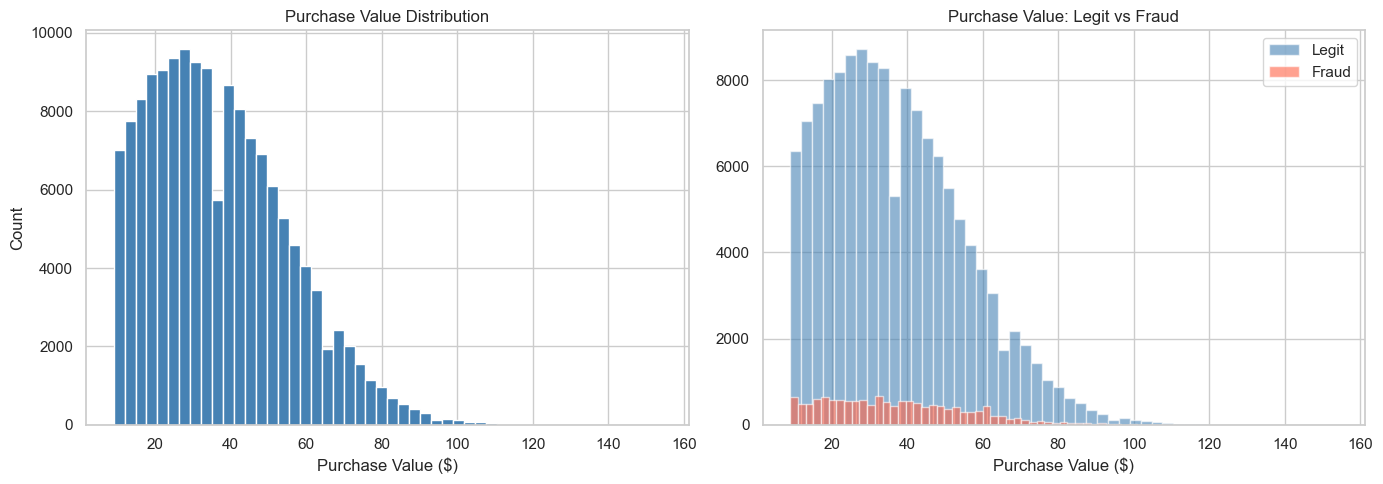

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(fraud_df['purchase_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Purchase Value Distribution')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Count')

# By class
fraud_df[fraud_df['class'] == 0]['purchase_value'].hist(
    bins=50, alpha=0.6, label='Legit', color='steelblue', ax=axes[1]
)
fraud_df[fraud_df['class'] == 1]['purchase_value'].hist(
    bins=50, alpha=0.6, label='Fraud', color='tomato', ax=axes[1]
)
axes[1].set_title('Purchase Value: Legit vs Fraud')
axes[1].set_xlabel('Purchase Value ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/purchase_value_distribution.png', dpi=150)
plt.show()

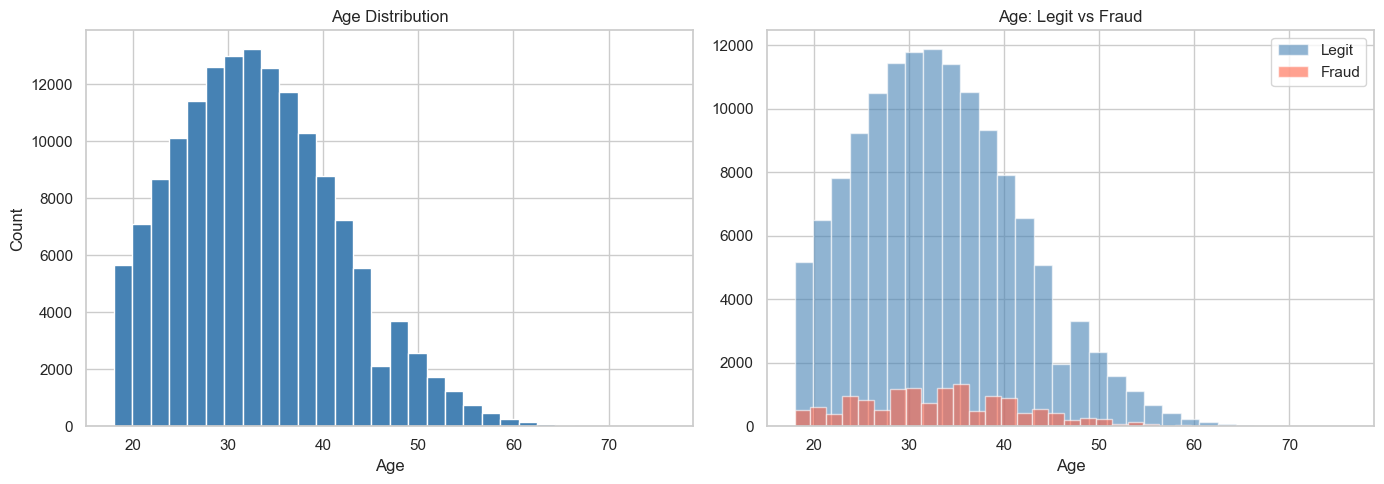

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fraud_df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

fraud_df[fraud_df['class'] == 0]['age'].hist(
    bins=30, alpha=0.6, label='Legit', color='steelblue', ax=axes[1]
)
fraud_df[fraud_df['class'] == 1]['age'].hist(
    bins=30, alpha=0.6, label='Fraud', color='tomato', ax=axes[1]
)
axes[1].set_title('Age: Legit vs Fraud')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/age_distribution.png', dpi=150)
plt.show()

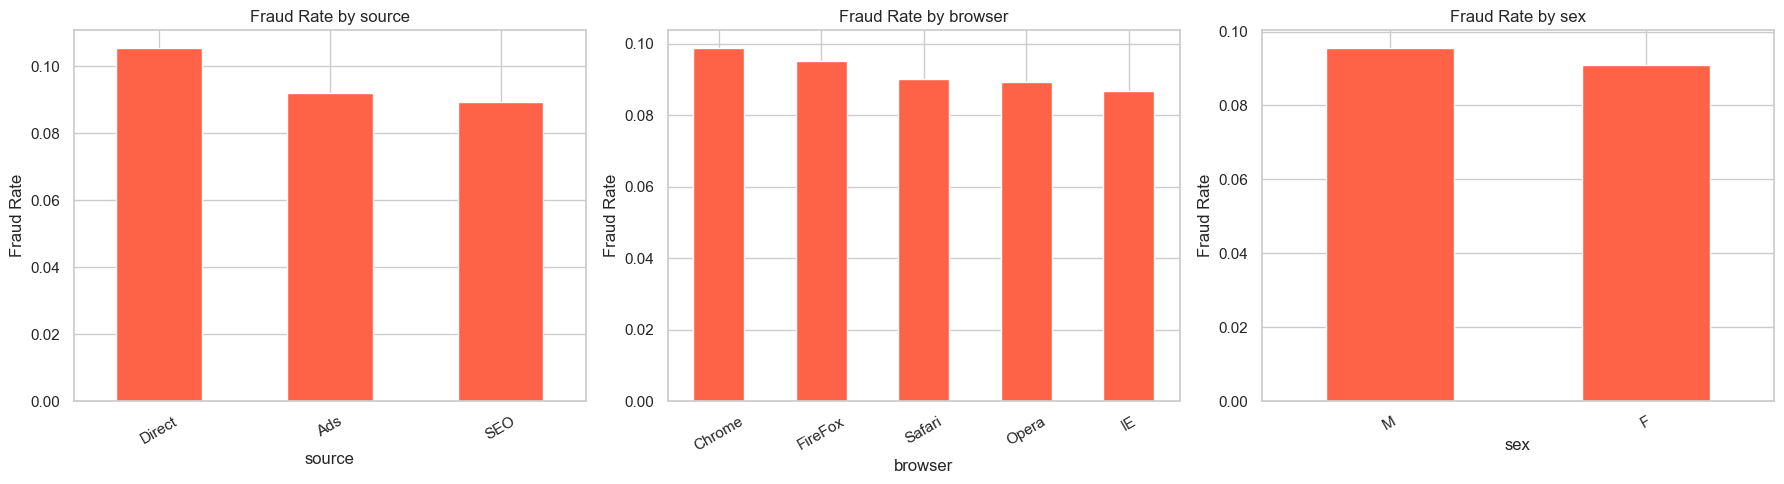

In [62]:
cat_cols = ['source', 'browser', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    fraud_rate = fraud_df.groupby(col)['class'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=axes[i], color='tomato', edgecolor='white')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fraud Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/fraud_rate_by_category.png', dpi=150)
plt.show()

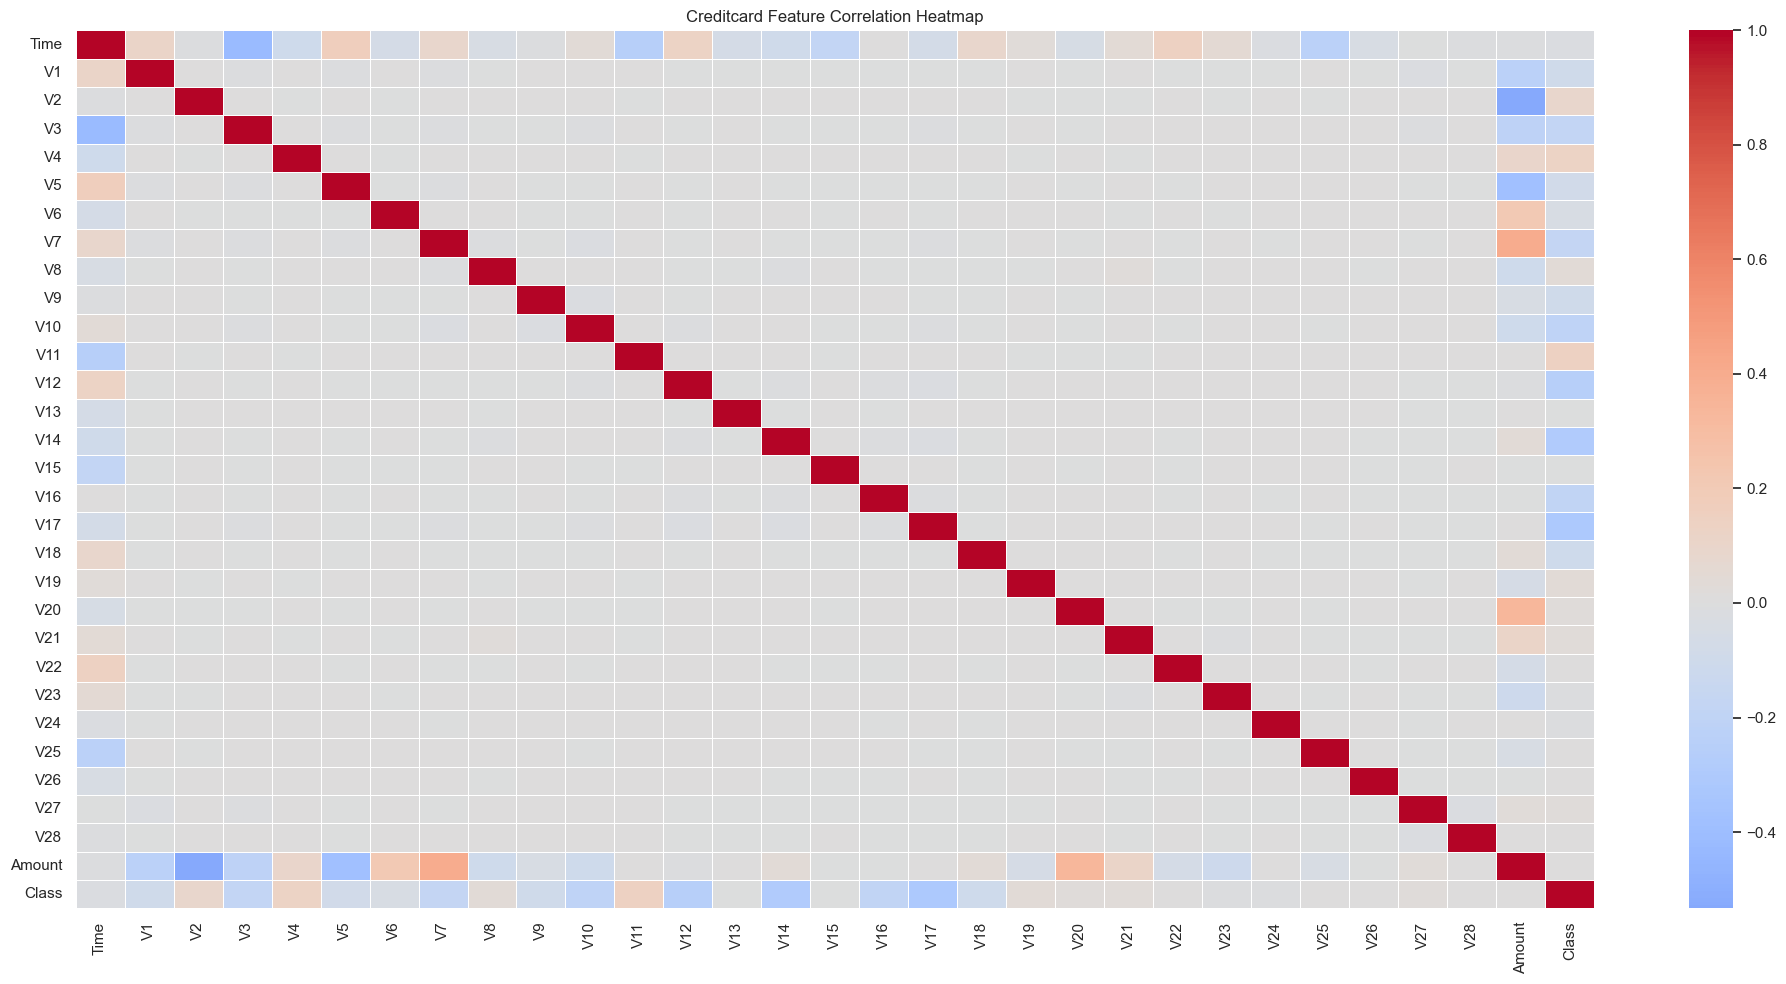

In [63]:
plt.figure(figsize=(20, 10))
corr = cc_df.corr()
sns.heatmap(
    corr, cmap='coolwarm', center=0,
    linewidths=0.5, annot=False
)
plt.title('Creditcard Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/processed/creditcard_correlation.png', dpi=150)
plt.show()

In [64]:
def ip_to_int(ip):
    try:
        parts = str(ip).strip().split('.')
        if len(parts) != 4:
            return None
        return (int(float(parts[0])) << 24) + \
               (int(float(parts[1])) << 16) + \
               (int(float(parts[2])) << 8)  + \
                int(float(parts[3]))
    except:
        return None

# Apply conversion
fraud_df['ip_int'] = fraud_df['ip_address'].apply(ip_to_int)

# ✅ CRITICAL — force to float64 to match ip_df
fraud_df['ip_int'] = fraud_df['ip_int'].astype('float64')

# Drop rows where conversion failed
fraud_df = fraud_df.dropna(subset=['ip_int'])

# Confirm types match
print("fraud_df ip_int type:        ", fraud_df['ip_int'].dtype)
print("ip_df lower_bound type:      ", ip_df['lower_bound_ip_address'].dtype)
print("ip_df upper_bound type:      ", ip_df['upper_bound_ip_address'].dtype)
print("\nSample ip_int values:")
print(fraud_df['ip_int'].head())
print("✅ Types match! Ready for merge.")

fraud_df ip_int type:         float64
ip_df lower_bound type:       float64
ip_df upper_bound type:       int64

Sample ip_int values:
Series([], Name: ip_int, dtype: float64)
✅ Types match! Ready for merge.


In [65]:
# Sort both dataframes — required for merge_asof
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)
fraud_df_sorted = fraud_df.sort_values('ip_int').reset_index(drop=True)

# Confirm types one more time before merge
print("Before merge:")
print("  fraud_df ip_int dtype:          ", fraud_df_sorted['ip_int'].dtype)
print("  ip_df lower_bound dtype:        ", ip_df_sorted['lower_bound_ip_address'].dtype)

# Range-based merge
fraud_merged = pd.merge_asof(
    fraud_df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Remove rows where ip_int is outside the upper bound
fraud_merged = fraud_merged[
    fraud_merged['ip_int'] <= fraud_merged['upper_bound_ip_address']
]

# Fill unmatched countries
fraud_merged['country'] = fraud_merged['country'].fillna('Unknown')

print("\nShape after geo merge:", fraud_merged.shape)
print("Countries found:", fraud_merged['country'].nunique())
print("\nSample result:")
print(fraud_merged[['ip_address', 'ip_int', 'country']].head(10))
print("✅ Merge complete!")

Before merge:
  fraud_df ip_int dtype:           float64
  ip_df lower_bound dtype:         float64

Shape after geo merge: (0, 15)
Countries found: 0

Sample result:
Empty DataFrame
Columns: [ip_address, ip_int, country]
Index: []
✅ Merge complete!


In [66]:
# Check what your ip_address column actually looks like
print("Sample IP values:")
print(fraud_df['ip_address'].head(20))

print("\nData type:", fraud_df['ip_address'].dtype)

print("\nAny nulls:", fraud_df['ip_address'].isnull().sum())

print("\nSample raw values (first 5):")
for val in fraud_df['ip_address'].head(5):
    print(f"  repr: {repr(val)}  |  type: {type(val)}")

Sample IP values:
Series([], Name: ip_address, dtype: float64)

Data type: float64

Any nulls: 0

Sample raw values (first 5):


In [67]:
# Check all your dataframes
print("fraud_df shape:        ", fraud_df.shape)
print("ip_df shape:           ", ip_df.shape)
print("cc_df shape:           ", cc_df.shape)

fraud_df shape:         (0, 12)
ip_df shape:            (138846, 3)
cc_df shape:            (283726, 31)


In [68]:
# Reload all raw data fresh
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df    = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
cc_df    = pd.read_csv('../data/raw/creditcard.csv')

print("Fraud_Data shape:          ", fraud_df.shape)
print("IpAddress_to_Country shape:", ip_df.shape)
print("creditcard shape:          ", cc_df.shape)

print("\nFraud_Data columns:")
print(fraud_df.columns.tolist())

print("\nSample IP values:")
print(fraud_df['ip_address'].head(10))

print("\nIP dtype:", fraud_df['ip_address'].dtype)

Fraud_Data shape:           (151112, 11)
IpAddress_to_Country shape: (138846, 3)
creditcard shape:           (284807, 31)

Fraud_Data columns:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']

Sample IP values:
0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_address, dtype: float64

IP dtype: float64


In [69]:
# ── 1. Fix data types ──────────────────────────────────────
fraud_df['signup_time']   = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# ── 2. Remove duplicates ───────────────────────────────────
fraud_df = fraud_df.drop_duplicates()
cc_df    = cc_df.drop_duplicates()

# ── 3. Drop nulls ──────────────────────────────────────────
fraud_df = fraud_df.dropna()
cc_df    = cc_df.dropna()

print("After cleaning:")
print("  fraud_df shape:", fraud_df.shape)
print("  cc_df shape:   ", cc_df.shape)
print("\nSample IP values:")
print(fraud_df['ip_address'].head(10))
print("\nIP dtype:", fraud_df['ip_address'].dtype)
print("✅ Cleaning done!")

After cleaning:
  fraud_df shape: (151112, 11)
  cc_df shape:    (283726, 31)

Sample IP values:
0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_address, dtype: float64

IP dtype: float64
✅ Cleaning done!


In [70]:
# IP addresses are already float numbers — just rename
fraud_df['ip_int'] = pd.to_numeric(fraud_df['ip_address'], errors='coerce')
fraud_df = fraud_df.dropna(subset=['ip_int'])

print("fraud_df shape:           ", fraud_df.shape)
print("ip_int dtype:             ", fraud_df['ip_int'].dtype)
print("lower_bound dtype:        ", ip_df['lower_bound_ip_address'].dtype)
print("\nSample ip_int:")
print(fraud_df['ip_int'].head(10))
print("✅ IP ready for merge!")

fraud_df shape:            (151112, 12)
ip_int dtype:              float64
lower_bound dtype:         float64

Sample ip_int:
0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_int, dtype: float64
✅ IP ready for merge!


In [71]:
# Sort both
ip_df_sorted    = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)
fraud_df_sorted = fraud_df.sort_values('ip_int').reset_index(drop=True)

# Merge
fraud_merged = pd.merge_asof(
    fraud_df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Filter outside upper bound
fraud_merged = fraud_merged[
    fraud_merged['ip_int'] <= fraud_merged['upper_bound_ip_address']
]

# Fill unmatched
fraud_merged['country'] = fraud_merged['country'].fillna('Unknown')

print("Shape after merge:", fraud_merged.shape)
print("Countries found:  ", fraud_merged['country'].nunique())
print("\nSample:")
print(fraud_merged[['ip_address', 'ip_int', 'country']].head(10))
print("✅ Merge complete!")

Shape after merge: (129146, 15)
Countries found:   181

Sample:
       ip_address        ip_int    country
634  1.677886e+07  1.677886e+07  Australia
635  1.684205e+07  1.684205e+07   Thailand
636  1.684366e+07  1.684366e+07      China
637  1.693873e+07  1.693873e+07      China
638  1.697198e+07  1.697198e+07   Thailand
639  1.699555e+07  1.699555e+07      China
640  1.709773e+07  1.709773e+07   Thailand
641  1.712443e+07  1.712443e+07      Japan
642  1.713459e+07  1.713459e+07      Japan
643  1.716216e+07  1.716216e+07      Japan
✅ Merge complete!


In [72]:
# time_since_signup in hours
fraud_merged['time_since_signup'] = (
    fraud_merged['purchase_time'] - fraud_merged['signup_time']
).dt.total_seconds() / 3600

# hour of day
fraud_merged['hour_of_day'] = fraud_merged['purchase_time'].dt.hour

# day of week
fraud_merged['day_of_week'] = fraud_merged['purchase_time'].dt.dayofweek

print("New time features:")
print(fraud_merged[[
    'signup_time', 'purchase_time',
    'time_since_signup', 'hour_of_day', 'day_of_week'
]].head(10))

print("\ntime_since_signup stats:")
print(fraud_merged['time_since_signup'].describe())
print("✅ Time features done!")

New time features:
            signup_time       purchase_time  time_since_signup  hour_of_day  \
634 2015-06-28 03:00:34 2015-08-09 03:57:29        1008.948611            3   
635 2015-01-28 14:21:11 2015-02-11 20:28:28         342.121389           20   
636 2015-03-19 20:49:09 2015-04-11 23:41:23         554.870556           23   
637 2015-02-24 06:11:57 2015-05-23 16:40:14        2122.471389           16   
638 2015-07-07 12:58:11 2015-11-03 04:04:30        2847.105278            4   
639 2015-06-15 21:47:39 2015-08-02 04:35:34        1134.798611            4   
640 2015-03-15 08:27:21 2015-05-21 13:55:15        1613.465000           13   
641 2015-01-17 14:38:23 2015-03-15 18:13:39        1371.587778           18   
642 2015-06-16 04:02:41 2015-07-25 01:29:33         933.447778            1   
643 2015-04-11 13:13:27 2015-07-03 22:27:10        2001.228611           22   

     day_of_week  
634            6  
635            2  
636            5  
637            5  
638            1

In [73]:
# Number of transactions per user
user_tx = fraud_merged.groupby('user_id')['purchase_time'] \
                      .count().reset_index()
user_tx.columns = ['user_id', 'user_transaction_count']

# Merge back
fraud_merged = fraud_merged.merge(user_tx, on='user_id', how='left')

print("Transaction velocity stats:")
print(fraud_merged['user_transaction_count'].describe())

print("\nHigh velocity users (more than 5 transactions):")
print(fraud_merged[fraud_merged['user_transaction_count'] > 5] \
      [['user_id', 'user_transaction_count', 'class']] \
      .head(10))
print("✅ Velocity feature done!")

Transaction velocity stats:
count    129146.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: user_transaction_count, dtype: float64

High velocity users (more than 5 transactions):
Empty DataFrame
Columns: [user_id, user_transaction_count, class]
Index: []
✅ Velocity feature done!


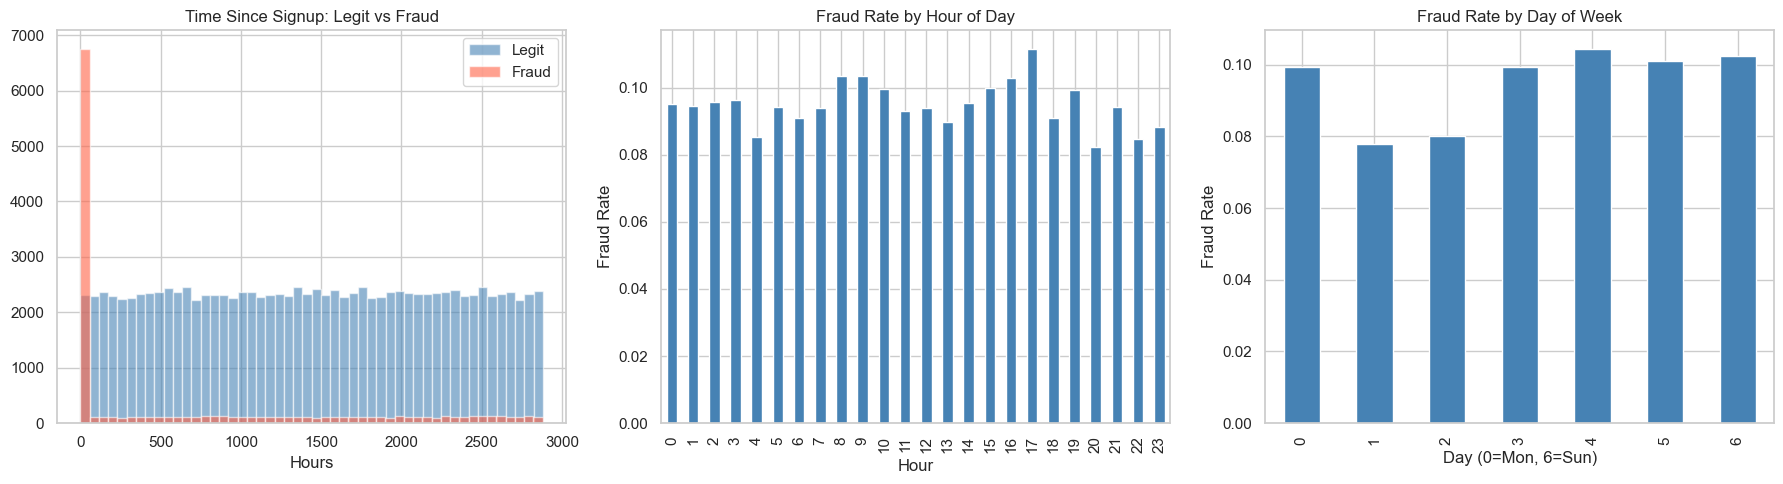

✅ Saved!


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# time_since_signup
fraud_merged[fraud_merged['class']==0]['time_since_signup'].hist(
    bins=50, alpha=0.6, label='Legit',
    color='steelblue', ax=axes[0]
)
fraud_merged[fraud_merged['class']==1]['time_since_signup'].hist(
    bins=50, alpha=0.6, label='Fraud',
    color='tomato', ax=axes[0]
)
axes[0].set_title('Time Since Signup: Legit vs Fraud')
axes[0].set_xlabel('Hours')
axes[0].legend()

# hour_of_day
fraud_merged.groupby('hour_of_day')['class'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

# day_of_week
fraud_merged.groupby('day_of_week')['class'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white'
)
axes[2].set_title('Fraud Rate by Day of Week')
axes[2].set_xlabel('Day (0=Mon, 6=Sun)')
axes[2].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig('../data/processed/engineered_features.png', dpi=150)
plt.show()
print("✅ Saved!")

In [75]:
# Work on a copy
fraud_model = fraud_merged.copy()

# Drop columns not needed for modeling
drop_cols = [
    'user_id', 'device_id', 'ip_address',
    'signup_time', 'purchase_time',
    'ip_int', 'lower_bound_ip_address',
    'upper_bound_ip_address', 'country'
]
fraud_model = fraud_model.drop(columns=drop_cols, errors='ignore')

# One-hot encode categoricals
cat_cols = ['source', 'browser', 'sex']
fraud_model = pd.get_dummies(
    fraud_model, columns=cat_cols, drop_first=True
)

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = [
    'purchase_value', 'age', 'time_since_signup',
    'hour_of_day', 'day_of_week', 'user_transaction_count'
]
fraud_model[num_cols] = scaler.fit_transform(fraud_model[num_cols])

print("Shape after transformation:", fraud_model.shape)
print("\nColumns:")
print(fraud_model.columns.tolist())
print("\nSample:")
print(fraud_model.head(3))
print("✅ Encoding and scaling done!")

Shape after transformation: (129146, 14)

Columns:
['purchase_value', 'age', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_transaction_count', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']

Sample:
   purchase_value       age  class  time_since_signup  hour_of_day  \
0        0.549607 -0.363124      0          -0.413800    -1.231124   
1       -1.197335  0.101168      0          -1.180852     1.229002   
2        0.385831 -0.479197      0          -0.936126     1.663142   

   day_of_week  user_transaction_count  source_Direct  source_SEO  \
0     1.487911                     0.0          False        True   
1    -0.505034                     0.0          False        True   
2     0.989675                     0.0          False       False   

   browser_FireFox  browser_IE  browser_Opera  browser_Safari  sex_M  
0            False       False          False            True  False  
1            False  

In [76]:
from sklearn.preprocessing import StandardScaler

cc_scaler = StandardScaler()

# Only scale Amount and Time
cc_df[['Amount', 'Time']] = cc_scaler.fit_transform(
    cc_df[['Amount', 'Time']]
)

print("Creditcard Amount and Time scaled:")
print(cc_df[['Amount', 'Time']].describe().round(2))
print("✅ Done!")

Creditcard Amount and Time scaled:
          Amount       Time
count  283726.00  283726.00
mean       -0.00       0.00
std         1.00       1.00
min        -0.35      -2.00
25%        -0.33      -0.86
50%        -0.27      -0.21
75%        -0.04       0.94
max       102.25       1.64
✅ Done!


In [77]:
from sklearn.model_selection import train_test_split

# Fraud_Data
X_fraud = fraud_model.drop('class', axis=1)
y_fraud = fraud_model['class']

# Creditcard
X_cc = cc_df.drop('Class', axis=1)
y_cc = cc_df['Class']

# Split both — stratified
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = \
    train_test_split(
        X_fraud, y_fraud,
        test_size=0.2, random_state=42, stratify=y_fraud
    )

X_cc_train, X_cc_test, y_cc_train, y_cc_test = \
    train_test_split(
        X_cc, y_cc,
        test_size=0.2, random_state=42, stratify=y_cc
    )

print("Fraud_Data splits:")
print("  Train:", X_fraud_train.shape,
      "| Fraud train %:", round(y_fraud_train.mean()*100, 2))
print("  Test: ", X_fraud_test.shape,
      "| Fraud test %: ", round(y_fraud_test.mean()*100, 2))

print("\nCreditcard splits:")
print("  Train:", X_cc_train.shape,
      "| Fraud train %:", round(y_cc_train.mean()*100, 2))
print("  Test: ", X_cc_test.shape,
      "| Fraud test %: ", round(y_cc_test.mean()*100, 2))
print("✅ Split done!")

Fraud_Data splits:
  Train: (103316, 13) | Fraud train %: 9.5
  Test:  (25830, 13) | Fraud test %:  9.5

Creditcard splits:
  Train: (226980, 30) | Fraud train %: 0.17
  Test:  (56746, 30) | Fraud test %:  0.17
✅ Split done!


In [78]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Fraud_Data
X_fraud_train_sm, y_fraud_train_sm = smote.fit_resample(
    X_fraud_train, y_fraud_train
)

# Creditcard
X_cc_train_sm, y_cc_train_sm = smote.fit_resample(
    X_cc_train, y_cc_train
)

print("=== Fraud_Data ===")
print("BEFORE SMOTE:", pd.Series(y_fraud_train).value_counts().to_dict())
print("AFTER SMOTE: ", pd.Series(y_fraud_train_sm).value_counts().to_dict())

print("\n=== Creditcard ===")
print("BEFORE SMOTE:", pd.Series(y_cc_train).value_counts().to_dict())
print("AFTER SMOTE: ", pd.Series(y_cc_train_sm).value_counts().to_dict())
print("\n✅ SMOTE applied on training sets only!")

=== Fraud_Data ===
BEFORE SMOTE: {0: 93502, 1: 9814}
AFTER SMOTE:  {0: 93502, 1: 93502}

=== Creditcard ===
BEFORE SMOTE: {0: 226602, 1: 378}
AFTER SMOTE:  {0: 226602, 1: 226602}

✅ SMOTE applied on training sets only!


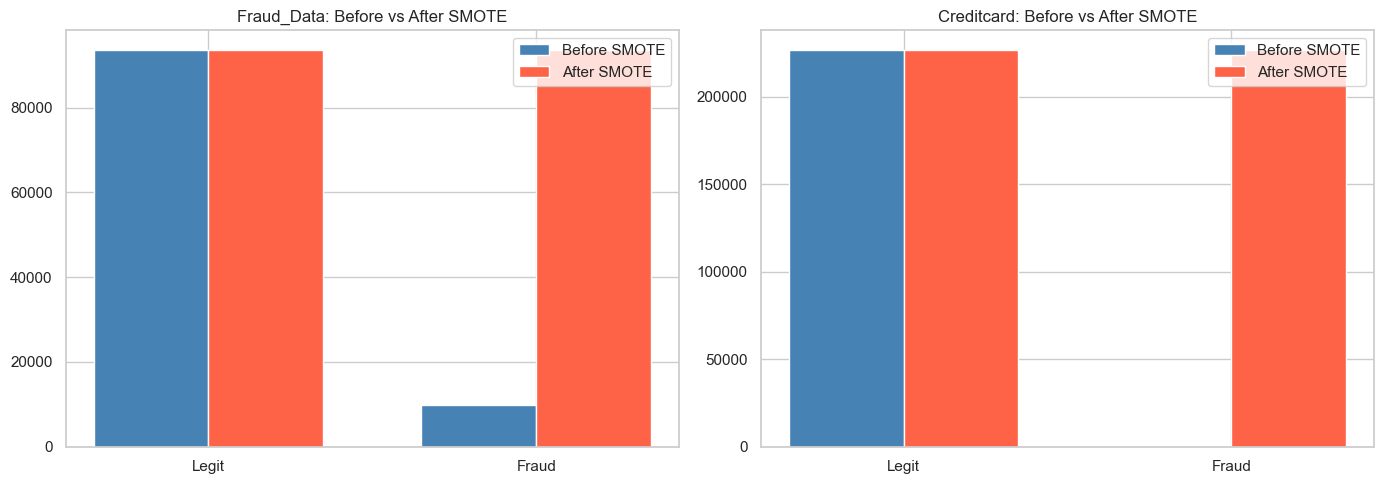

✅ Saved!


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud_Data
before_fraud = pd.Series(y_fraud_train).value_counts()
after_fraud  = pd.Series(y_fraud_train_sm).value_counts()

x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, before_fraud, width,
            label='Before SMOTE', color='steelblue')
axes[0].bar(x + width/2, after_fraud,  width,
            label='After SMOTE',  color='tomato')
axes[0].set_title('Fraud_Data: Before vs After SMOTE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Legit', 'Fraud'])
axes[0].legend()

# Creditcard
before_cc = pd.Series(y_cc_train).value_counts()
after_cc  = pd.Series(y_cc_train_sm).value_counts()

axes[1].bar(x - width/2, before_cc, width,
            label='Before SMOTE', color='steelblue')
axes[1].bar(x + width/2, after_cc,  width,
            label='After SMOTE',  color='tomato')
axes[1].set_title('Creditcard: Before vs After SMOTE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Legit', 'Fraud'])
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/smote_comparison.png', dpi=150)
plt.show()
print("✅ Saved!")

In [80]:
import numpy as np
import os

# Save processed CSVs
fraud_model.to_csv('../data/processed/fraud_data_processed.csv', index=False)
cc_df.to_csv('../data/processed/creditcard_processed.csv', index=False)

# Save train/test splits as numpy arrays
np.save('../data/processed/X_fraud_train.npy', X_fraud_train_sm)
np.save('../data/processed/y_fraud_train.npy', y_fraud_train_sm)
np.save('../data/processed/X_fraud_test.npy',  X_fraud_test.values)
np.save('../data/processed/y_fraud_test.npy',  y_fraud_test.values)

np.save('../data/processed/X_cc_train.npy', X_cc_train_sm)
np.save('../data/processed/y_cc_train.npy', y_cc_train_sm)
np.save('../data/processed/X_cc_test.npy',  X_cc_test.values)
np.save('../data/processed/y_cc_test.npy',  y_cc_test.values)

# Save column names for modeling notebook
import json
with open('../data/processed/fraud_feature_columns.json', 'w') as f:
    json.dump(X_fraud.columns.tolist(), f)

print("✅ All files saved!")
print("\nFiles in data/processed/:")
for f in sorted(os.listdir('../data/processed/')):
    size = os.path.getsize(f'../data/processed/{f}')
    print(f"  {f:45s} {size:>10,} bytes")

✅ All files saved!

Files in data/processed/:
  X_cc_test.npy                                 13,619,168 bytes
  X_cc_train.npy                                108,769,088 bytes
  X_fraud_test.npy                               1,576,585 bytes
  X_fraud_train.npy                             11,412,393 bytes
  age_distribution.png                              53,540 bytes
  class_distribution.png                            15,567 bytes
  creditcard_class_distribution.png                 50,059 bytes
  creditcard_correlation.png                        93,297 bytes
  creditcard_processed.csv                      157,860,467 bytes
  engineered_features.png                           80,371 bytes
  fraud_class_distribution.png                      54,582 bytes
  fraud_data_processed.csv                      18,772,591 bytes
  fraud_feature_columns.json                           210 bytes
  fraud_rate_by_category.png                        64,910 bytes
  purchase_value_distribution.png         

In [81]:
print("=" * 55)
print("       TASK 1 COMPLETE — SUMMARY REPORT")
print("=" * 55)

print("\n📦 DATASETS:")
print(f"  Fraud_Data rows:        {fraud_merged.shape[0]:,}")
print(f"  Creditcard rows:        {cc_df.shape[0]:,}")

print("\n🧹 CLEANING:")
print("  ✅ Timestamps fixed")
print("  ✅ Duplicates removed")
print("  ✅ Missing values handled")

print("\n🌍 GEOLOCATION:")
print(f"  ✅ IP merged to country")
print(f"  ✅ Countries found: {fraud_merged['country'].nunique()}")

print("\n⚙️  FEATURES ENGINEERED:")
print("  ✅ time_since_signup (hours)")
print("  ✅ hour_of_day")
print("  ✅ day_of_week")
print("  ✅ user_transaction_count")

print("\n🔄 TRANSFORMATION:")
print("  ✅ One-hot encoding done")
print("  ✅ StandardScaler applied")

print("\n⚖️  CLASS IMBALANCE:")
print(f"  Before SMOTE fraud %: "
      f"{round(y_fraud_train.mean()*100,2)}%")
print(f"  After SMOTE fraud %:  "
      f"{round(pd.Series(y_fraud_train_sm).mean()*100,2)}%")
print("  ✅ SMOTE on training only — no data leakage")

print("\n💾 SAVED FILES:")
print("  ✅ fraud_data_processed.csv")
print("  ✅ creditcard_processed.csv")
print("  ✅ Train/test .npy arrays")
print("  ✅ All EDA plots as .png")


       TASK 1 COMPLETE — SUMMARY REPORT

📦 DATASETS:
  Fraud_Data rows:        129,146
  Creditcard rows:        283,726

🧹 CLEANING:
  ✅ Timestamps fixed
  ✅ Duplicates removed
  ✅ Missing values handled

🌍 GEOLOCATION:
  ✅ IP merged to country
  ✅ Countries found: 181

⚙️  FEATURES ENGINEERED:
  ✅ time_since_signup (hours)
  ✅ hour_of_day
  ✅ day_of_week
  ✅ user_transaction_count

🔄 TRANSFORMATION:
  ✅ One-hot encoding done
  ✅ StandardScaler applied

⚖️  CLASS IMBALANCE:
  Before SMOTE fraud %: 9.5%
  After SMOTE fraud %:  50.0%
  ✅ SMOTE on training only — no data leakage

💾 SAVED FILES:
  ✅ fraud_data_processed.csv
  ✅ creditcard_processed.csv
  ✅ Train/test .npy arrays
  ✅ All EDA plots as .png
